# 06: Lab - Data Scraping

This practice notebook provides additional preparation for Assignment 6. 

## Setup
* Import packages: `requests`, `BeautifulSoup` (from `bs4`), `pandas` (as `pd`), `seaborn` (as `sns`)
* Set your Seaborn theme's style, context, and any runtime configurations you wish

In [2]:
#Import packages
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns

#Set Seaborn theme
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind', font_scale=0.8, rc={"axes.titlesize":20})

## Scraping Exercises

### 1. Scrape 2024 electricity usage data from the EIA 
Let's scrape data the US Energy Administration's State Electricity Archive:
<https://www.eia.gov/electricity/state/>

1. Navigate to the page. Note the year for which these data are provided.
2. Use the Selector Gadget tool to scrape the following values into variables: 
    * State name
    * Average Retail price
    * Net summer capacity
    * Net generation
    * Total retail sales
3. Compile the data into a dataframe
4. Examine the dataframe

**Recall that the BeautifulSoup scraping workflow is as follows**: 
1. Retrieve to the website contents using the `requests.get()` function.
1. Parse the contents into "soup" using BeautifulSoup.
1. Extract specific elements--or *element sets*--in the web site via their node IDs, found using Selector Gadget
    - Convert into lists using list comprehension<br>*Hint:* `[items.get_text(strip=True) for items in the_website.select('<nodeID>')]`
1. Wrangle values into a dataframe
    - Note that scraped values are always returned as strings; you'll need to manually convert these to numeric values (`float` or `int`)
    - Also note that with numbers scraped with a comma separator (e.g. `1,000`), the comma needs to be removed;  `str.replace(',','')` is helpful here
1. Examine the column information for your dataframe.
1. [Optional] Construct a regression plot (`regplot`) showing the relationship of total retail sales to net generation of electricity. 

<Axes: xlabel='Net_Gen', ylabel='Total_Retail_Sales'>

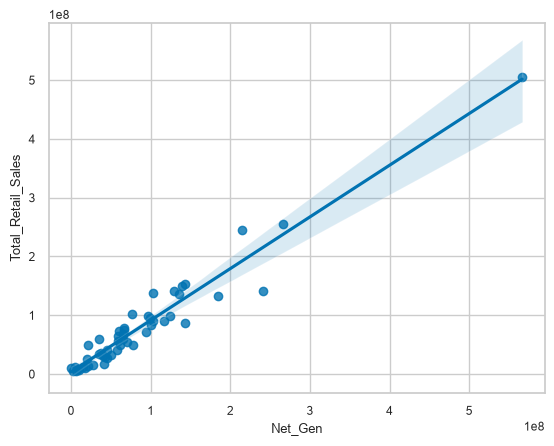

In [24]:
# 1.1 Fetch and parse the website
url = 'https://www.eia.gov/electricity/state/'

response = requests.get(url)
response.raise_for_status()

webpage = BeautifulSoup(response.text, "html.parser")

# 1.2 Locate elements and read their text attributes into variables
state_name = webpage.select('td:nth-child(1)')
state_name = [node.get_text(strip=True) for node in state_name]

avg_retail_price = webpage.select('td:nth-child(2)')
avg_retail_price = [node.get_text(strip=True) for node in avg_retail_price]

net_summer_cap = webpage.select('td:nth-child(3)')
net_summer_cap = [node.get_text(strip=True) for node in net_summer_cap]

net_gen = webpage.select('td:nth-child(4)')
net_gen = [node.get_text(strip=True) for node in net_gen]

total_retail_sales = webpage.select('td:nth-child(5)')
total_retail_sales = [node.get_text(strip=True) for node in total_retail_sales]

  
# 1.3 Construct a dataframe from the values
df_eia = pd.DataFrame({
    'State' : state_name,
    'Avg_Retail_Price':avg_retail_price,
    'Net_Summer_Cap':net_summer_cap,
    'Net_Gen':net_gen,
    'Total_Retail_Sales':total_retail_sales
})


# 1.4 Wrangle
df_eia['Net_Gen'] = pd.to_numeric(df_eia['Net_Gen'].str.replace(",",""))
df_eia['Avg_Retail_Price'] = pd.to_numeric(df_eia['Avg_Retail_Price'])
df_eia['Net_Summer_Cap'] = pd.to_numeric(df_eia['Net_Summer_Cap'].str.replace(",",""))
df_eia['Total_Retail_Sales'] = pd.to_numeric(df_eia['Total_Retail_Sales'].str.replace(",",""))

df_eia = df_eia.loc[df_eia['State'] != 'U.S. Total']

# 1.5 Examine
df_eia.head()

# 1.6. Plot
sns.regplot(
    data=df_eia,
    x='Net_Gen',
    y='Total_Retail_Sales'
)

### 2. Repeat, for a different year
* Copy and paste your code in the code chunk below, then modify it to fetch the same data for 2023
    - Note that the URL takes a slightly different format than 2024, but the HTML tags remain the same. 

<Axes: xlabel='Net_Gen', ylabel='Total_Retail_Sales'>

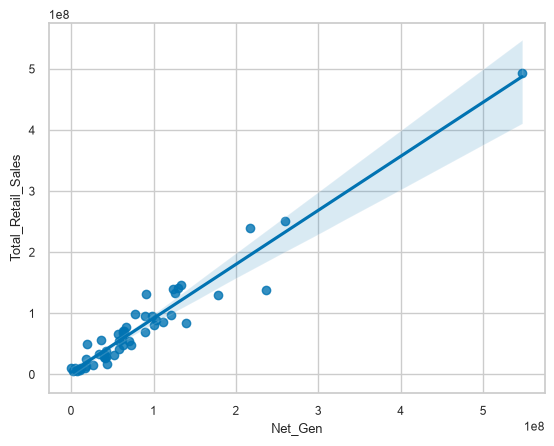

In [25]:
#Copy and paste code from above; then modify to scrape data for 2023
# 1.1 Fetch and parse the website
url = 'https://www.eia.gov/electricity/state/archive/2023/'

response = requests.get(url)
response.raise_for_status()

webpage = BeautifulSoup(response.text, "html.parser")

# 1.2 Locate elements and read their text attributes into variables
state_name = webpage.select('td:nth-child(1)')
state_name = [node.get_text(strip=True) for node in state_name]

avg_retail_price = webpage.select('td:nth-child(2)')
avg_retail_price = [node.get_text(strip=True) for node in avg_retail_price]

net_summer_cap = webpage.select('td:nth-child(3)')
net_summer_cap = [node.get_text(strip=True) for node in net_summer_cap]

net_gen = webpage.select('td:nth-child(4)')
net_gen = [node.get_text(strip=True) for node in net_gen]

total_retail_sales = webpage.select('td:nth-child(5)')
total_retail_sales = [node.get_text(strip=True) for node in total_retail_sales]

  
# 1.3 Construct a dataframe from the values
df_eia = pd.DataFrame({
    'State' : state_name,
    'Avg_Retail_Price':avg_retail_price,
    'Net_Summer_Cap':net_summer_cap,
    'Net_Gen':net_gen,
    'Total_Retail_Sales':total_retail_sales
})


# 1.4 Wrangle
df_eia['Net_Gen'] = pd.to_numeric(df_eia['Net_Gen'].str.replace(",",""))
df_eia['Avg_Retail_Price'] = pd.to_numeric(df_eia['Avg_Retail_Price'])
df_eia['Net_Summer_Cap'] = pd.to_numeric(df_eia['Net_Summer_Cap'].str.replace(",",""))
df_eia['Total_Retail_Sales'] = pd.to_numeric(df_eia['Total_Retail_Sales'].str.replace(",",""))

df_eia = df_eia.loc[df_eia['State'] != 'U.S. Total']

# 1.5 Examine
df_eia.head()

# 1.6. Plot
sns.regplot(
    data=df_eia,
    x='Net_Gen',
    y='Total_Retail_Sales'
)

### 3. Create a scraping *function* to accept a year as the input
* Note, you'll need to add an `if` statement to check whether the year is 2024 or not as the URL changes for years before 2024
* Add a `year` column to the dataframe, setting its value to the year supplied when the function is called. 

In [32]:
# 3. Create a scrape function
def scrape_it(the_year):

    # 3.1 Form the base url based on whether the year is 2024 or not
    if the_year == 2024:
        url = 'https://www.eia.gov/electricity/state/'
    else: url = f"https://www.eia.gov/electricity/state/archive/{the_year}/"

    # 3.2 Fetch & parse the website
    response = requests.get(url)
    response.raise_for_status()

    webpage = BeautifulSoup(response.text, "html.parser")

    # 3.3 Extract the data to list variables
    state_name = webpage.select('td:nth-child(1)')
    state_name = [node.get_text(strip=True) for node in state_name]

    avg_retail_price = webpage.select('td:nth-child(2)')
    avg_retail_price = [node.get_text(strip=True) for node in avg_retail_price]

    net_summer_cap = webpage.select('td:nth-child(3)')
    net_summer_cap = [node.get_text(strip=True) for node in net_summer_cap]

    net_gen = webpage.select('td:nth-child(4)')
    net_gen = [node.get_text(strip=True) for node in net_gen]

    total_retail_sales = webpage.select('td:nth-child(5)')
    total_retail_sales = [node.get_text(strip=True) for node in total_retail_sales]

    # 3.4 Construct a dataframe from the extracted list variables
    df_eia = pd.DataFrame({
    'State' : state_name,
    'Avg_Retail_Price':avg_retail_price,
    'Net_Summer_Cap':net_summer_cap,
    'Net_Gen':net_gen,
    'Total_Retail_Sales':total_retail_sales
    })

    # 3.5 Wrangle as needed
    df_eia['Net_Gen'] = pd.to_numeric(df_eia['Net_Gen'].str.replace(",",""))
    df_eia['Avg_Retail_Price'] = pd.to_numeric(df_eia['Avg_Retail_Price'])
    df_eia['Net_Summer_Cap'] = pd.to_numeric(df_eia['Net_Summer_Cap'].str.replace(",",""))
    df_eia['Total_Retail_Sales'] = pd.to_numeric(df_eia['Total_Retail_Sales'].str.replace(",",""))

    df_eia = df_eia.loc[df_eia['State'] != 'U.S. Total']

    df_eia = df_eia.assign(
        Year = the_year
    )

    # 3.6 Return the dataframe
    return df_eia

### 4. Use the function to scrape data for 2017

In [33]:
#Use the function to scrape data for 2017
df_2017 = scrape_it(2017)
df_2017.head()

,State,Avg_Retail_Price,Net_Summer_Cap,Net_Gen,Total_Retail_Sales,Year
0,Alabama,9.83,29725,139964250,86241730,2017
1,Alaska,19.10,2749,6497466,6185799,2017
2,Arizona,10.64,28595,105851721,77646262,2017
3,Arkansas,8.26,14642,60775298,46085951,2017
4,California,16.06,76414,206146392,257267937,2017


### 5. Use the function to scrape data for 2017-2024
* Construct dataframes for each year
* Concatenate the dataframes into a single dataframe
* Plot electricity prices for Virginia, North Carolina, and South Carolina for the span 2017-2024

In [34]:
# 5.1 Extract and concatenate the dataframes
df_range = pd.concat(
    [scrape_it(the_year) for the_year in range(2017,2025)]
)

df_range.head()

,State,Avg_Retail_Price,Net_Summer_Cap,Net_Gen,Total_Retail_Sales,Year
0,Alabama,9.83,29725,139964250,86241730,2017
1,Alaska,19.10,2749,6497466,6185799,2017
2,Arizona,10.64,28595,105851721,77646262,2017
3,Arkansas,8.26,14642,60775298,46085951,2017
4,California,16.06,76414,206146392,257267937,2017


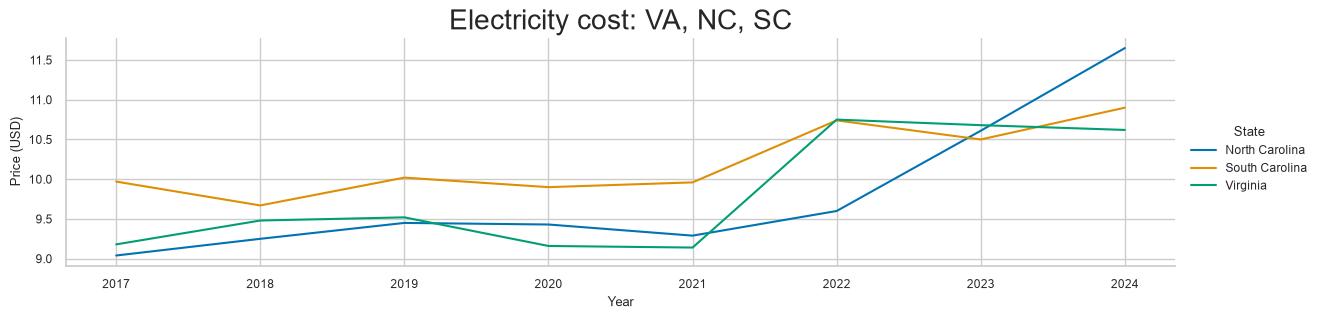

In [35]:
# 5.2 Plot electricity cost for VA, NC, SC
sns.relplot(
    data=df_range[df_range['State'].isin(['Virginia','North Carolina','South Carolina'])],
    x='Year',
    y='Avg_Retail_Price',
    hue='State',
    kind='line',
    height=3,
    aspect=4
).set(
    title='Electricity cost: VA, NC, SC',
    xlabel='Year',
    ylabel='Price (USD)'
);